# Tutorial 02 - Covariance & Variogram Model Gallery + Categorical Spatial Dependence

**Package:** stamps_v3  
**MATLAB equivalent:** `MODELSLIBtutorial.m`  
**Dataset:** Falmagne soil dataset (soil-type codes for categorical analysis)

---

## Learning objectives

1. Visualise the full gallery of **covariance models** (`*C` functions).
2. Visualise the full gallery of **variogram models** (`*V` functions).
3. Demonstrate the mathematical duality: $C(h) = C(0) - \gamma(h)$.
4. Build and plot a **nested covariance model** (nugget + two spherical structures).
5. Compute **empirical bivariate probability tables** for the categorical soil-type variable using `probatablecalc`, revealing the spatial dependence between soil categories.


In [1]:
import warnings
# Suppress rpy2 deprecation warning that fires when stamps loads its
# optional R-based sub-modules (dlnm, gam, stl). This must come
# BEFORE any stamps import so the filter is active when the package
# initialises for the first time in this kernel session.
warnings.filterwarnings(
    'ignore',
    message=r'.*activate.*deprecated.*|.*deactivate.*deprecated.*',
    category=DeprecationWarning,
)

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from stamps.stamps.models.covmodel import (
    nuggetC, exponentialC, sphericalC, gaussianC, holecosC, holesinC, mexicanhatC, maternC,
    nuggetV, exponentialV, sphericalV, gaussianV, holecosV, holesinV, linearV, powerV,
    get_model,
)
from stamps.stamps.general.coord2K import coord2K
from stamps.stamps.graph.modelplot import covmodel_plot
from stamps.stamps.graph.categorical import plot_pmodel_matrix

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
DATA_DIR = os.path.join(os.getcwd(), 'data')

# Load data from Tutorial 01
with open(os.path.join(DATA_DIR, 'tutorial01_data.pkl'), 'rb') as f:
    d = pickle.load(f)
ch   = d['ch']; code = d['code']
print('Loaded Falmagne data:', ch.shape)


Loaded Falmagne data: (118, 2)


## 1. Distance vector for plotting

All covariance / variogram models in stamps_v3 accept a **distance matrix** as their first argument.  For 1-D plotting we pass a row vector of lags.


In [2]:
h = np.linspace(0, 2.0, 300)  # dimensionless lag (units of the range)
# practical range ar=1 throughout this section for visual comparison
ar = 1.0
sill = 1.0


## 2. Covariance model gallery

All `*C` functions follow: `C = model(dist, sill, ar)`, where
- `sill` is the variance (plateau value at $h = 0$)
- `ar` is the **practical range** (distance where $C \approx 0.05 \cdot \text{sill}$)

> **Exception:** `holecosC(dist, a_half, p_half)` uses amplitude/periodicity parameterisation.  
> **Exception:** `maternC(dist, sill, [ar, shape])` takes a list for the last parameter.  
> **Exception:** `mexicanhatC(dist, sill, b, c)` takes three shape parameters.


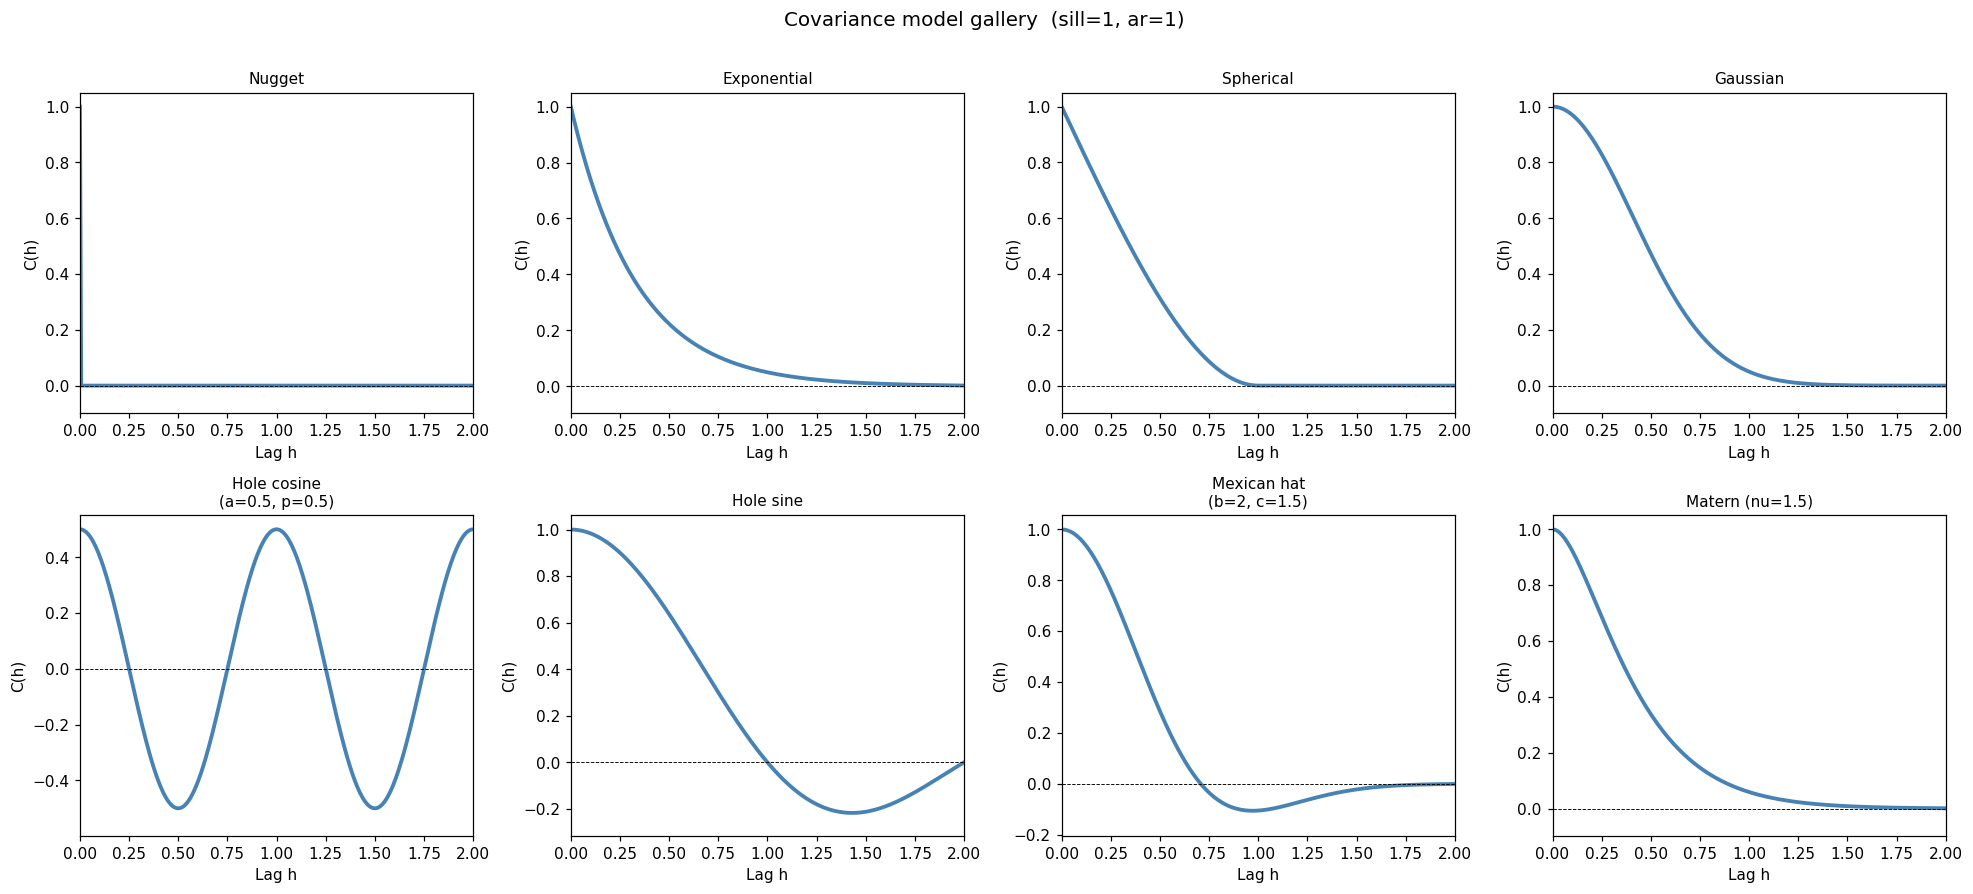

In [3]:
cov_defs = [
    (lambda h: nuggetC(h, sill),              h, None, 'Nugget'),
    (lambda h: exponentialC(h, sill, ar),     h, None, 'Exponential'),
    (lambda h: sphericalC(h, sill, ar),       h, None, 'Spherical'),
    (lambda h: gaussianC(h, sill, ar),        h, None, 'Gaussian'),
    (lambda h: holecosC(h, 0.5, 0.5),        h, None, 'Hole cosine\n(a=0.5, p=0.5)'),
    (lambda h: holesinC(h, sill, ar),         h, None, 'Hole sine'),
    (lambda h: mexicanhatC(h, sill, 2.0, 1.5), h, None, 'Mexican hat\n(b=2, c=1.5)'),
    (lambda h: maternC(h, sill, [ar, 1.5]),   h, None, 'Matern (nu=1.5)'),
]

covmodel_plot(cov_defs, covparam=None)


## 3. Variogram model gallery

Variogram functions $\gamma(h)$ satisfy $\gamma(0) = 0$ and increase with lag.
All `*V` functions follow: `V = model(dist, sill, ar)` (same convention as `*C`).  

Two **intrinsic** models (`linearV`, `powerV`) have no finite sill:
- `linearV(dist, slope)` — slope replaces sill
- `powerV(dist, slope, exponent)` — slope + exponent


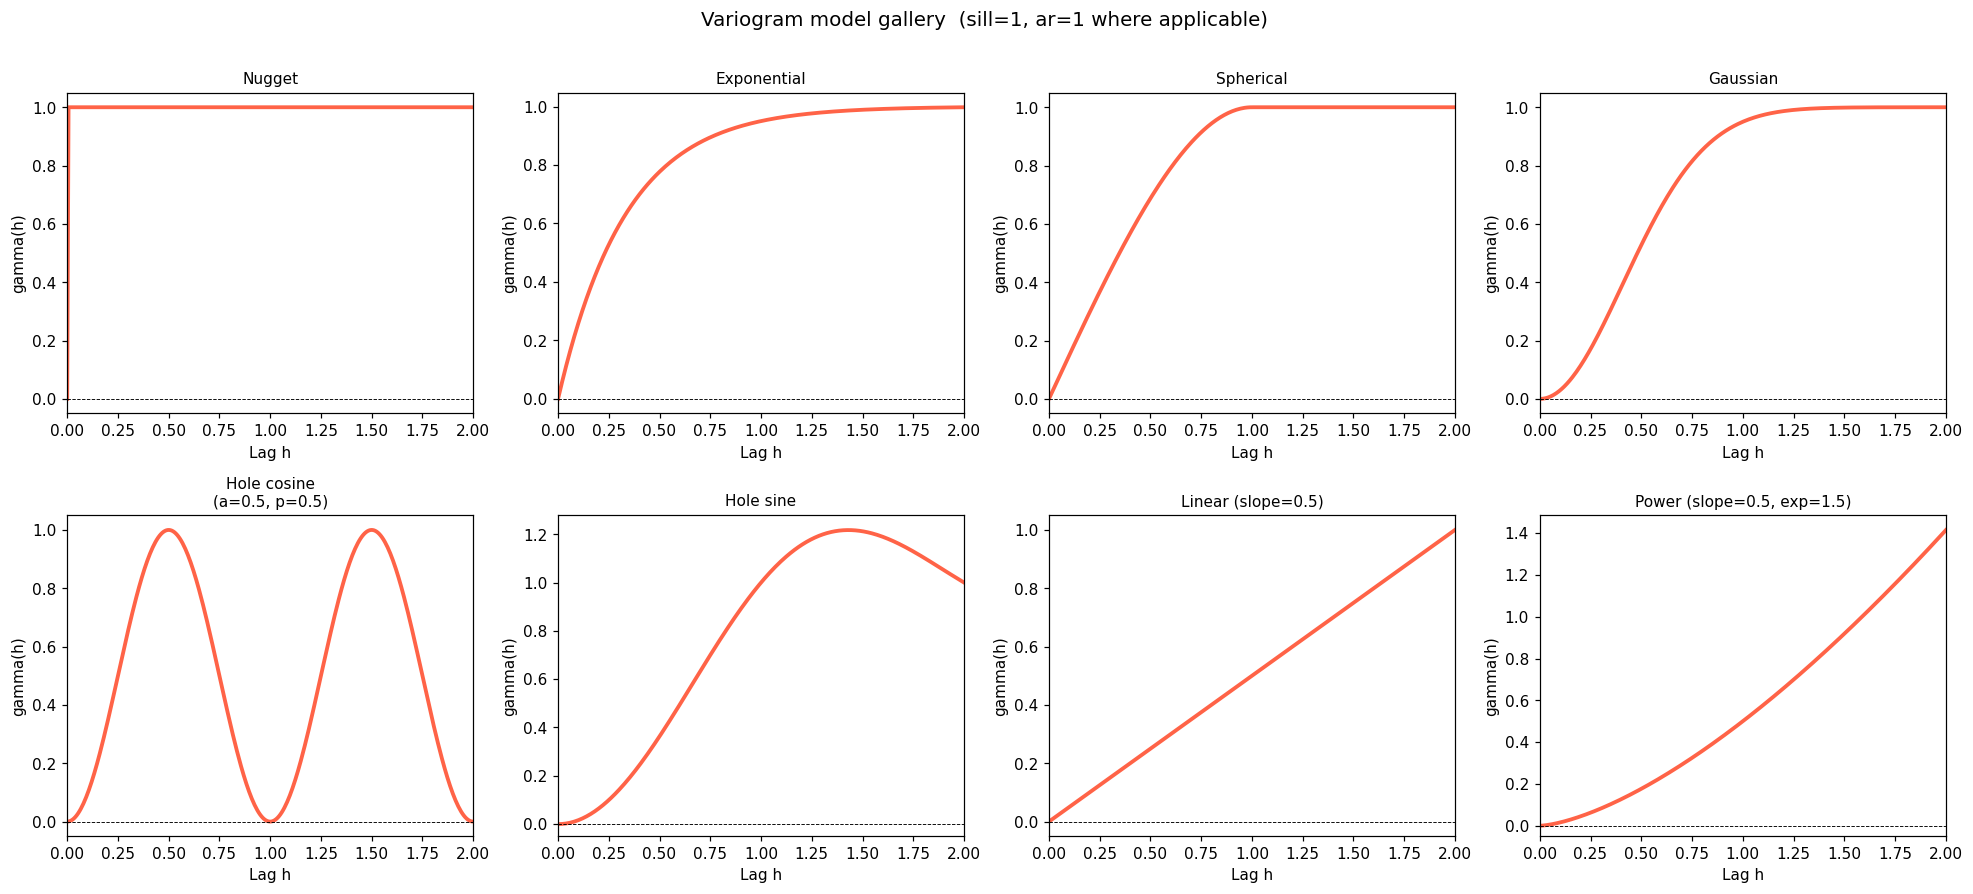

In [4]:
var_defs = [
    (lambda h: nuggetV(h, sill),              h, None, 'Nugget'),
    (lambda h: exponentialV(h, sill, ar),     h, None, 'Exponential'),
    (lambda h: sphericalV(h, sill, ar),       h, None, 'Spherical'),
    (lambda h: gaussianV(h, sill, ar),        h, None, 'Gaussian'),
    (lambda h: holecosV(h, 0.5, 0.5),        h, None, 'Hole cosine\n(a=0.5, p=0.5)'),
    (lambda h: holesinV(h, sill, ar),         h, None, 'Hole sine'),
    (lambda h: linearV(h, 0.5),              h, None, 'Linear (slope=0.5)'),
    (lambda h: powerV(h, 0.5, 1.5),          h, None, 'Power (slope=0.5, exp=1.5)'),
]

covmodel_plot(var_defs, covparam=None, ch2semi=False)


## 4. Mathematical duality: $C(h)$ vs $\gamma(h)$

For a stationary random field with variance $\sigma^2 = C(0)$:

$$\gamma(h) = C(0) - C(h)$$

This means a covariance model and its variogram counterpart carry exactly the same information.  stamps_v3 provides both for user convenience — you can work in whichever representation you prefer.


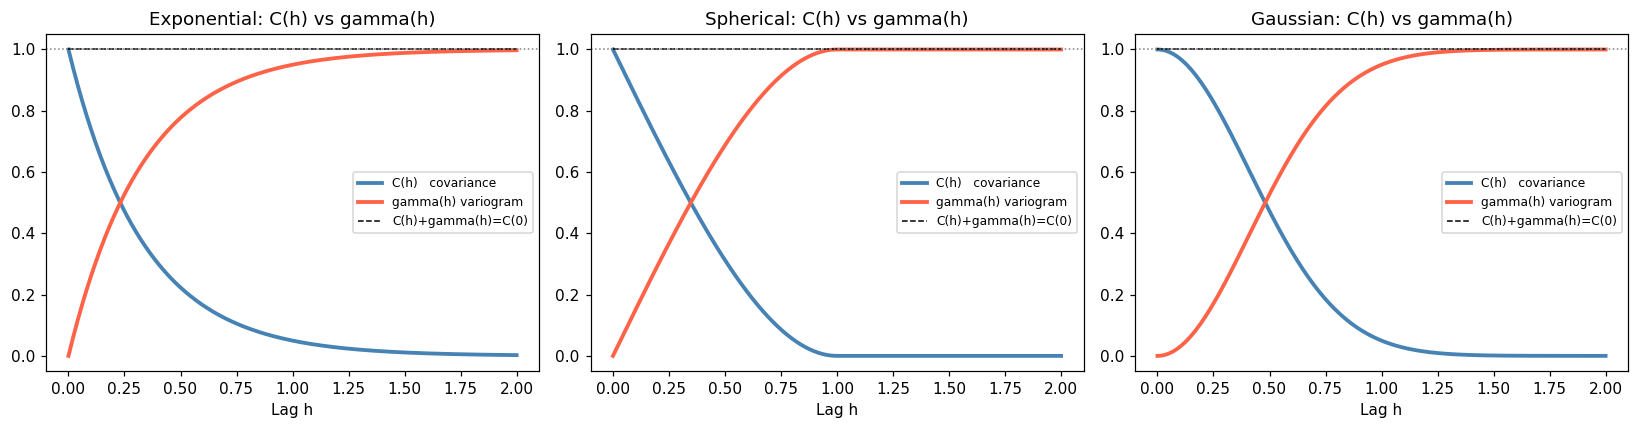

C(0) = 1.0   [dashed line == C(0)]


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [('Exponential', exponentialC, exponentialV),
          ('Spherical',   sphericalC,   sphericalV),
          ('Gaussian',    gaussianC,    gaussianV)]

for ax, (name, Cfn, Vfn) in zip(axes, models):
    C = Cfn(h, sill, ar)
    V = Vfn(h, sill, ar)
    ax.plot(h, C,            'steelblue', lw=2.5, label='C(h)   covariance')
    ax.plot(h, V,            'tomato',    lw=2.5, label='gamma(h) variogram')
    ax.plot(h, C + V,        'k--',       lw=1,   label='C(h)+gamma(h)=C(0)')
    ax.axhline(sill, color='gray', ls=':', lw=1)
    ax.set_xlabel('Lag h'); ax.set_title(f'{name}: C(h) vs gamma(h)')
    ax.legend(fontsize=8)

plt.tight_layout(); plt.show()
print('C(0) =', sill, '  [dashed line == C(0)]')


## 5. Nested covariance model

A **nested model** sums several basic structures to capture variability at multiple spatial scales.  In stamps_v3, a nested model is specified as:

```python
covmodel = ['nuggetC', 'sphericalC', 'sphericalC']
covparam = [(c0,), (c1, a1), (c2, a2)]
```

and evaluated via `coord2K(c1, c2, covmodel, covparam)`.


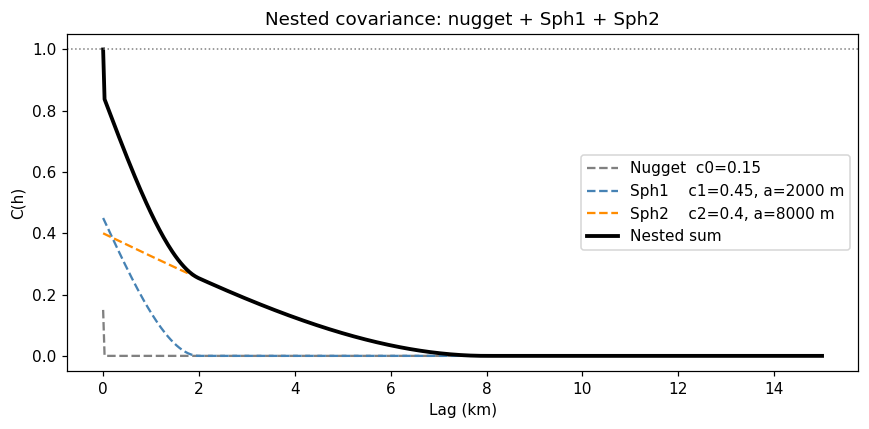

In [6]:
# Nested model: nugget + short-range spherical + long-range spherical
c0, c1, c2 = 0.15, 0.45, 0.40     # sills (sum = 1.0)
a1, a2     = 2_000, 8_000          # ranges in metres

# Evaluate manually over a lag vector for plotting
h_m = np.linspace(0, 15_000, 500)  # lags in metres
C_nested = (nuggetC(h_m, c0)
           + sphericalC(h_m, c1, a1)
           + sphericalC(h_m, c2, a2))

# Plot with modelplot using stamps format
from stamps.stamps.graph.modelplot import modelplot

covmodel_nested = ['nuggetC', 'sphericalC', 'sphericalC']
covparam_nested = [[c0], [c1, [a1]], [c2, [a2]]]

axs = modelplot(C_nested[:, np.newaxis], h_m, covmodel=covmodel_nested,
                covparam=covparam_nested, components=True, lag_scale=1000,
                lag_unit='km')
axs[0].set_title('Nested covariance: nugget + Sph1 + Sph2')
plt.tight_layout(); plt.show()


## 6. Categorical spatial dependence — `probatablecalc`

The Falmagne dataset contains a **soil type code** (1–4).  Unlike a continuous variable, its spatial dependence cannot be captured by a single covariance function.  Instead, we use **bivariate probability tables** $P_{k\ell}(h)$, defined as:

$$P_{k\ell}(h) = \Pr\!\left[Z(\mathbf{s}) = k \;\wedge\; Z(\mathbf{s}+\mathbf{h}) = \ell\right]$$

At lag $h = 0$, the diagonal entries $P_{kk}(0)$ equal the **proportion** of category $k$.  As lag increases, $P_{kk}(h)$ decays toward $p_k^2$ (independence), revealing the spatial persistence of each soil type.

stamps_v3 function: `stamps.stamps.stats.dependence.probatablecalc.probatablecalc`


In [7]:
from stamps.stamps.stats.dependence import probatablecalc

# Build indicator (one-hot) matrix for soil types 1-4
categories = np.unique(code)
nc = len(categories)   # 4 soil types
indicators = np.zeros((len(code), nc))
for j, cat in enumerate(categories):
    indicators[:, j] = (code == cat).astype(float)

print(f'Categories: {categories}')
print('Indicator matrix shape:', indicators.shape)
print('Column sums (proportions):', indicators.sum(axis=0) / len(code))

# Distance bins: 0..12000 m in 1 km steps
coord_limit = np.arange(0, 13_000, 1_000).astype(float)

D, P, O = probatablecalc(ch, indicators, coord_limit)
print(f'Distance lags: {D.shape[0]} bins')
print(f'Probability table shape: {P.shape}  (nc x nc x nlags)')
print(f'Pairs per lag bin: {O}')


Categories: [1 2 3 4]
Indicator matrix shape: (118, 4)
Column sums (proportions): [0.05932203 0.20338983 0.27118644 0.46610169]
Distance lags: 13 bins
Probability table shape: (4, 4, 13)  (nc x nc x nlags)
Pairs per lag bin: [118. 170. 209. 316. 326. 452. 494. 485. 580. 543. 527. 592. 422.]


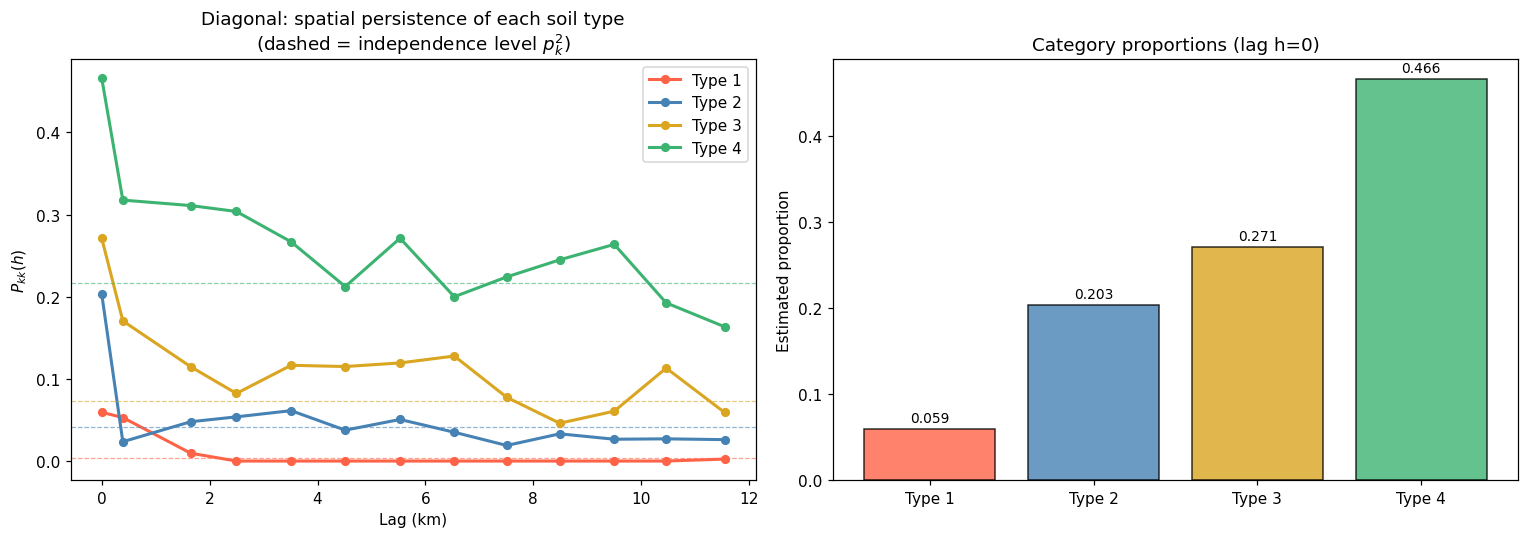

In [8]:
cat_colors = ['tomato', 'steelblue', 'goldenrod', 'mediumseagreen']
cat_names  = [f'Type {k}' for k in categories]

# Use plot_pmodel_matrix restricted to diagonal categories only
# for a compact persistence summary (one panel per category)
fig, ax_full = plot_pmodel_matrix(
    D, P, O,
    categories=list(categories), labels=cat_names, colors=cat_colors,
    x_label='Lag (km)', x_scale=1_000,
    suptitle='Diagonal: spatial persistence of each soil type\n(dashed = independence level)',
    show_independence=True, empirical_style='line',
)
# Highlight only the diagonal subplots and hide off-diagonal
nc = len(categories)
for i in range(nc):
    for j in range(nc):
        ax_full[i, j].set_visible(i == j)

# Proportion bar chart in a separate figure
p_k = np.array([P[j, j, 0] for j in range(nc)])
fig2, ax2 = plt.subplots(figsize=(6, 4))
bars = ax2.bar(cat_names, p_k, color=cat_colors, edgecolor='k', alpha=0.8)
for bar, v in zip(bars, p_k):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9)
ax2.set_ylabel('Estimated proportion'); ax2.set_title('Category proportions (lag h=0)')
plt.tight_layout(); plt.show()


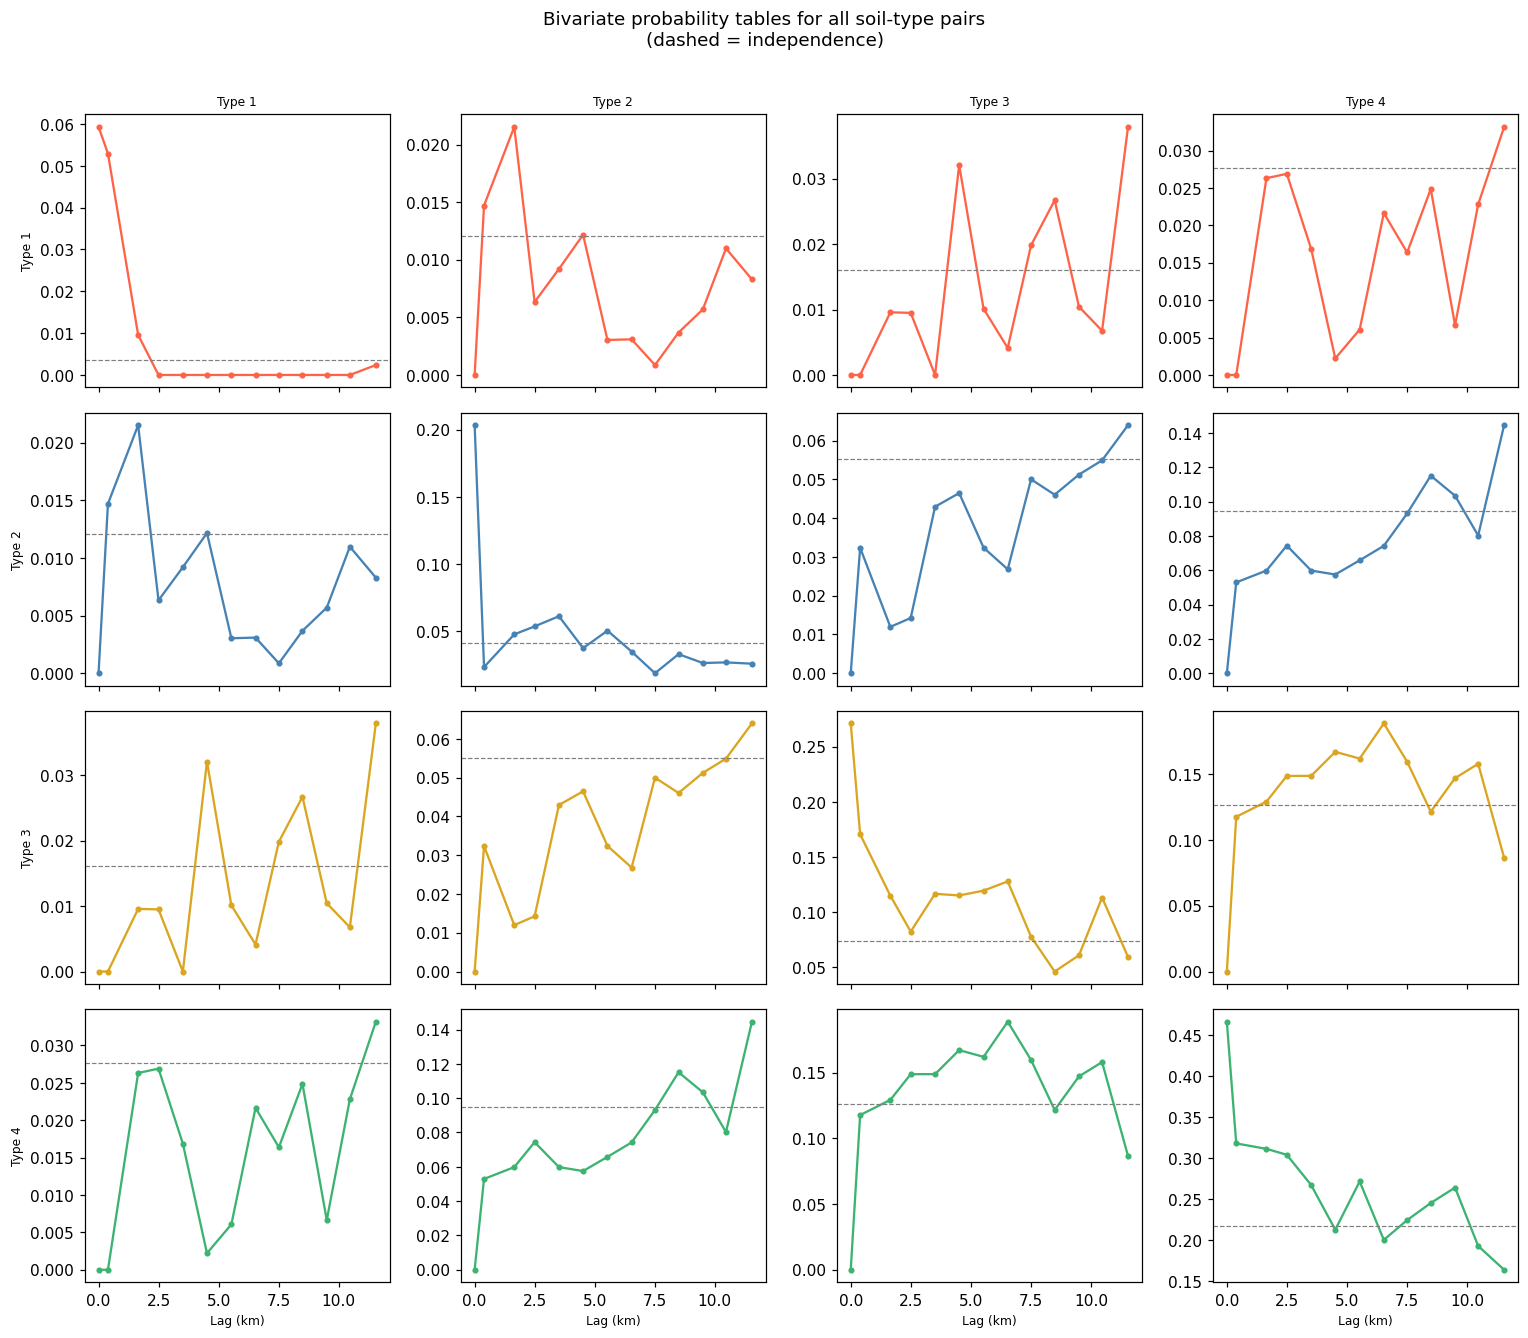

In [9]:
cat_colors = ['tomato', 'steelblue', 'goldenrod', 'mediumseagreen']
cat_names  = [f'Type {k}' for k in categories]

plot_pmodel_matrix(
    D, P, O,
    categories=list(categories), labels=cat_names, colors=cat_colors,
    x_label='Lag (km)', x_scale=1_000,
    suptitle='Bivariate probability tables for all soil-type pairs\n(dashed = independence)',
    show_independence=True, empirical_style='line',
)
plt.show()


## 7. Summary

| What we covered | Key takeaway |
|---|---|
| `*C` model gallery | 8 covariance models; all take `(dist, sill, ar)` |
| `*V` model gallery | 8 variogram models; same convention + 2 intrinsic (no sill) |
| C/gamma duality | $C(h) + \gamma(h) = C(0)$ always |
| Nested model | Sum basic structures to capture multi-scale variability |
| `probatablecalc` | Categorical analogue of the variogram; reveals how soil-type persistence decays with distance |

**Next:** Tutorial 03 — Empirical covariance estimation and WLS model fitting.
